In [59]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings

warnings.filterwarnings("ignore")

In [31]:
df = pd.read_csv("D:\PROJECTS\ML\Online_fraud_detection\data\onlinefraud.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [33]:
df.size

69988820

In [34]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [35]:
df.duplicated

<bound method DataFrame.duplicated of          step      type      amount     nameOrig  oldbalanceOrg  \
0           1   PAYMENT     9839.64  C1231006815      170136.00   
1           1   PAYMENT     1864.28  C1666544295       21249.00   
2           1  TRANSFER      181.00  C1305486145         181.00   
3           1  CASH_OUT      181.00   C840083671         181.00   
4           1   PAYMENT    11668.14  C2048537720       41554.00   
...       ...       ...         ...          ...            ...   
6362615   743  CASH_OUT   339682.13   C786484425      339682.13   
6362616   743  TRANSFER  6311409.28  C1529008245     6311409.28   
6362617   743  CASH_OUT  6311409.28  C1162922333     6311409.28   
6362618   743  TRANSFER   850002.52  C1685995037      850002.52   
6362619   743  CASH_OUT   850002.52  C1280323807      850002.52   

         newbalanceOrig     nameDest  oldbalanceDest  newbalanceDest  isFraud  \
0             160296.36  M1979787155            0.00            0.00        

In [36]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [37]:
df.describe

<bound method NDFrame.describe of          step      type      amount     nameOrig  oldbalanceOrg  \
0           1   PAYMENT     9839.64  C1231006815      170136.00   
1           1   PAYMENT     1864.28  C1666544295       21249.00   
2           1  TRANSFER      181.00  C1305486145         181.00   
3           1  CASH_OUT      181.00   C840083671         181.00   
4           1   PAYMENT    11668.14  C2048537720       41554.00   
...       ...       ...         ...          ...            ...   
6362615   743  CASH_OUT   339682.13   C786484425      339682.13   
6362616   743  TRANSFER  6311409.28  C1529008245     6311409.28   
6362617   743  CASH_OUT  6311409.28  C1162922333     6311409.28   
6362618   743  TRANSFER   850002.52  C1685995037      850002.52   
6362619   743  CASH_OUT   850002.52  C1280323807      850002.52   

         newbalanceOrig     nameDest  oldbalanceDest  newbalanceDest  isFraud  \
0             160296.36  M1979787155            0.00            0.00        0   

In [38]:
df = df.drop(["nameOrig", "nameDest"], axis=1)

In [39]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [40]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [41]:
df = df.drop(["isFlaggedFraud"], axis=1)

In [42]:
df = df.sample(100000, random_state=42)

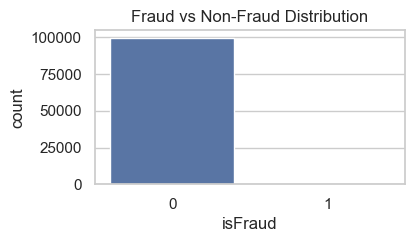

isFraud
0    99.859
1     0.141
Name: proportion, dtype: float64


In [43]:
plt.figure(figsize=(4, 2))
sns.countplot(x="isFraud", data=df)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

print(df["isFraud"].value_counts(normalize=True) * 100)

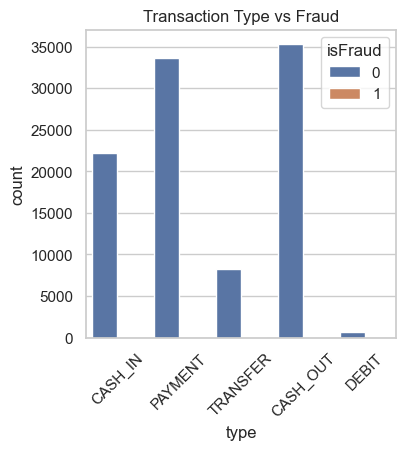

type
TRANSFER    0.946221
CASH_OUT    0.175468
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64


In [60]:
plt.figure(figsize=(4, 4))
sns.countplot(x="type", hue="isFraud", data=df)
plt.title("Transaction Type vs Fraud")
plt.xticks(rotation=45)
plt.show()

# Percentage fraud per type
fraud_by_type = df.groupby("type")["isFraud"].mean() * 100
print(fraud_by_type.sort_values(ascending=False))

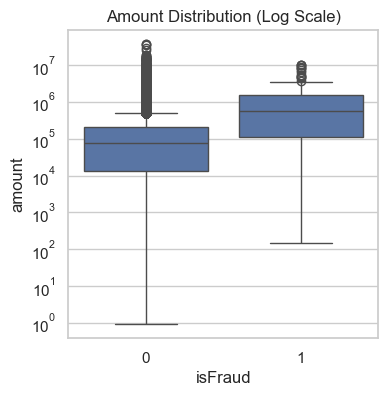

In [61]:
plt.figure(figsize=(4, 4))
sns.boxplot(x="isFraud", y="amount", data=df)
plt.yscale("log")  # important due to skew
plt.title("Amount Distribution (Log Scale)")
plt.show()

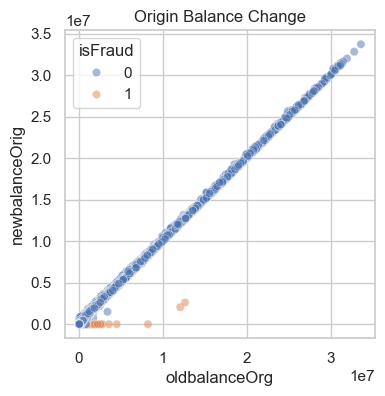

In [62]:
plt.figure(figsize=(4, 4))
sns.scatterplot(
    x="oldbalanceOrg",
    y="newbalanceOrig",
    hue="isFraud",
    data=df.sample(50000),
    alpha=0.5,
)
plt.title("Origin Balance Change")
plt.show()

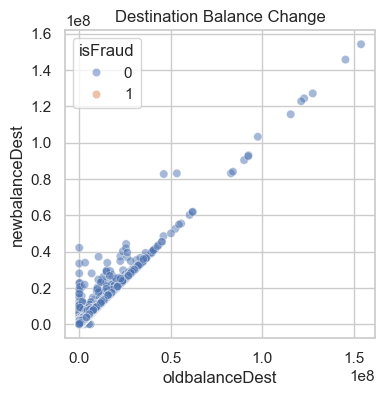

In [63]:
plt.figure(figsize=(4, 4))
sns.scatterplot(
    x="oldbalanceDest",
    y="newbalanceDest",
    hue="isFraud",
    data=df.sample(50000),
    alpha=0.5,
)
plt.title("Destination Balance Change")
plt.show()

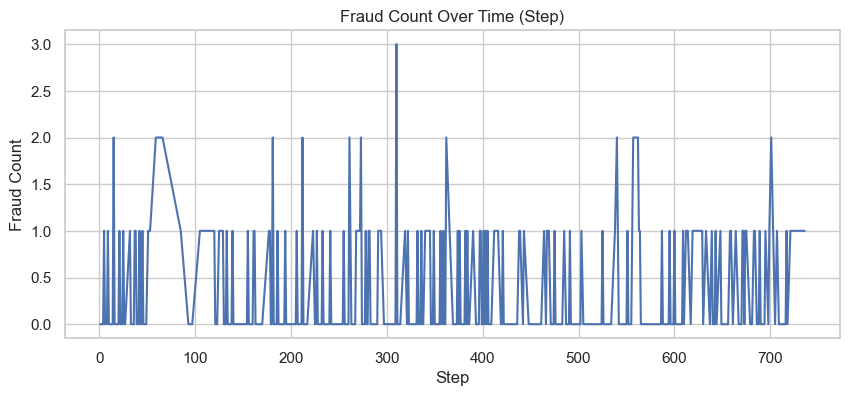

In [48]:
fraud_by_step = df.groupby("step")["isFraud"].sum()

plt.figure(figsize=(10, 4))
fraud_by_step.plot()
plt.title("Fraud Count Over Time (Step)")
plt.xlabel("Step")
plt.ylabel("Fraud Count")
plt.show()

In [49]:
df["isZeroOrig"] = (df["oldbalanceOrg"] == 0).astype(int)
df["isZeroDest"] = (df["oldbalanceDest"] == 0).astype(int)

print(
    "Zero Origin vs Fraud:\n",
    pd.crosstab(df["isZeroOrig"], df["isFraud"], normalize="index"),
)
print(
    "\nZero Destination vs Fraud:\n",
    pd.crosstab(df["isZeroDest"], df["isFraud"], normalize="index"),
)

Zero Origin vs Fraud:
 isFraud            0         1
isZeroOrig                    
0           0.997895  0.002105
1           1.000000  0.000000

Zero Destination vs Fraud:
 isFraud            0         1
isZeroDest                    
0           0.999273  0.000727
1           0.997656  0.002344


In [50]:
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balanceDiffDest"] = df["newbalanceDest"] - df["oldbalanceDest"]

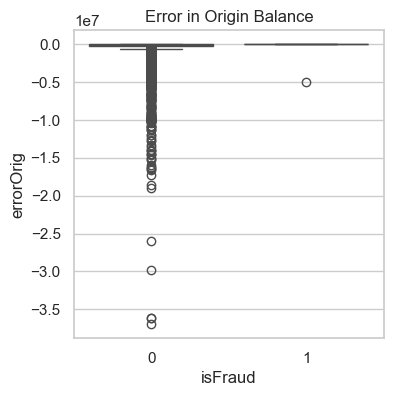

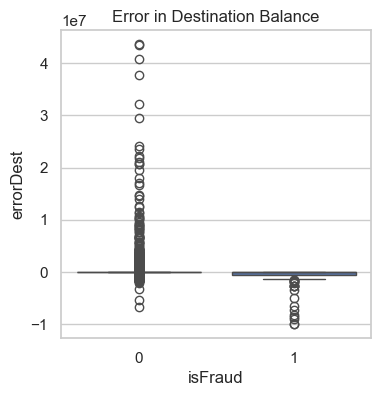

In [64]:
df["errorOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"] - df["amount"]
df["errorDest"] = df["newbalanceDest"] - df["oldbalanceDest"] - df["amount"]

plt.figure(figsize=(4, 4))
sns.boxplot(x="isFraud", y="errorOrig", data=df)
plt.title("Error in Origin Balance")
plt.show()

plt.figure(figsize=(4, 4))
sns.boxplot(x="isFraud", y="errorDest", data=df)
plt.title("Error in Destination Balance")
plt.show()

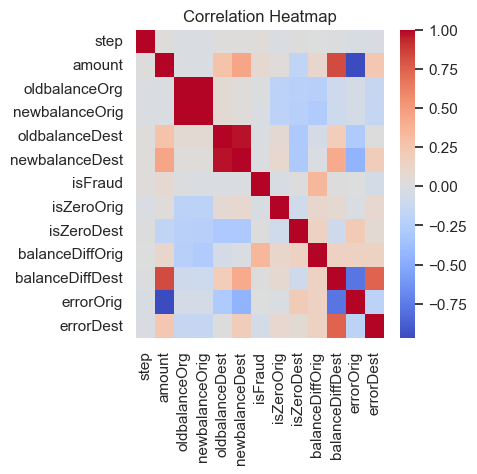

In [65]:
plt.figure(figsize=(4, 4))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 3. Feature Engineering
Creating derived features that capture the discrepancies in balances, which are strong indicators of fraud.

In [66]:
def create_derived_features(dataframe):
    df_copy = dataframe.copy()
    # Calculate balance errors
    df_copy["errorBalanceOrg"] = (
        df_copy["newbalanceOrig"] + df_copy["amount"] - df_copy["oldbalanceOrg"]
    )
    df_copy["errorBalanceDest"] = (
        df_copy["oldbalanceDest"] + df_copy["amount"] - df_copy["newbalanceDest"]
    )
    return df_copy


df_engineered = create_derived_features(df)
print("Engineered Features Added:")
display(df_engineered[["errorBalanceOrg", "errorBalanceDest"]].head())

Engineered Features Added:


,errorBalanceOrg,errorBalanceDest
3737323,660436.84,660436.84
264914,0.00,11647.08
85647,304528.42,304528.42
5899326,1551760.63,0.00
2544263,156344.60,156344.60


## 4. Train-Test Split

In [67]:
from sklearn.model_selection import train_test_split

target_column = "isFraud"
X = df_engineered.drop(columns=[target_column])
y = df_engineered[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (80000, 15)
X_test shape: (20000, 15)


## 5. Data Transformation (Preprocessing)
Building a ColumnTransformer to handle numerical scaling and categorical encoding.

In [68]:
numerical_columns = X_train.select_dtypes(exclude="object").columns.tolist()
categorical_columns = X_train.select_dtypes(include="object").columns.tolist()

num_pipeline = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)

cat_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ("scaler", StandardScaler(with_mean=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, numerical_columns),
        ("cat", cat_pipeline, categorical_columns),
    ]
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(f"Transformed X_train shape: {X_train_transformed.shape}")

Transformed X_train shape: (80000, 19)


In [70]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train_transformed, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_res.value_counts())

Before SMOTE:
 isFraud
0    79887
1      113
Name: count, dtype: int64

After SMOTE:
 isFraud
0    79887
1    79887
Name: count, dtype: int64


## 6. Model Training & Hyperparameter Tuning
We evaluate multiple models using GridSearchCV to find the best estimator based on ROC-AUC.

In [73]:
models = {
    "LogisticRegression": LogisticRegression(class_weight="balanced", max_iter=1000),
    "RandomForestClassifier": RandomForestClassifier(class_weight="balanced"),
    "XGBClassifier": XGBClassifier(
        scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),
        eval_metric="logloss",
    ),
}

from scipy.stats import randint, uniform

params = {
    "LogisticRegression": {"C": uniform(0.01, 10), "solver": ["liblinear"]},
    "RandomForestClassifier": {
        "n_estimators": randint(50, 200),
        "max_depth": randint(3, 15),
    },
    "XGBClassifier": {
        "n_estimators": randint(50, 200),
        "learning_rate": uniform(0.01, 0.2),
        "max_depth": randint(3, 10),
    },
}

In [77]:
from sklearn.model_selection import RandomizedSearchCV

best_models = {}

for model_name, model in models.items():
    print(f"\n===== Tuning {model_name} =====")

    rs = RandomizedSearchCV(
        model,
        param_distributions=params[model_name],
        n_iter=5,
        cv=3,
        scoring="recall",  # fraud focus
        n_jobs=-1,
        random_state=42,
    )

    rs.fit(X_train_transformed, y_train)

    best_models[model_name] = rs.best_estimator_

    print(f"Best Params: {rs.best_params_}")


===== Tuning LogisticRegression =====
Best Params: {'C': np.float64(3.7554011884736247), 'solver': 'liblinear'}

===== Tuning RandomForestClassifier =====
Best Params: {'max_depth': 13, 'n_estimators': 137}

===== Tuning XGBClassifier =====
Best Params: {'learning_rate': np.float64(0.0412037280884873), 'max_depth': 5, 'n_estimators': 124}


In [83]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    recall_score,
)

model_scores = {}

for model_name, model in best_models.items():
    print(f"\n===== Evaluating {model_name} =====")

    # TRAIN
    y_train_pred = model.predict(X_train_transformed)
    print("\n--- TRAIN REPORT ---")
    print(classification_report(y_train, y_train_pred))

    # TEST
    y_test_pred = model.predict(X_test_transformed)
    print("\n--- TEST REPORT ---")
    print(classification_report(y_test, y_test_pred))

    # PROBABILITIES (safe)
    if hasattr(model, "predict_proba"):
        train_probs = model.predict_proba(X_train_transformed)[:, 1]
        test_probs = model.predict_proba(X_test_transformed)[:, 1]
    else:
        train_probs = model.predict(X_train_transformed)
        test_probs = model.predict(X_test_transformed)

    # AUC
    train_auc = roc_auc_score(y_train, train_probs)
    test_auc = roc_auc_score(y_test, test_probs)

    print(f"\nTrain AUC: {train_auc:.4f}")
    print(f"Test AUC: {test_auc:.4f}")

    # Recall (MOST IMPORTANT)
    recall = recall_score(y_test, y_test_pred)
    print(f"Recall (Fraud Detection): {recall:.4f}")

    # Confusion Matrix
    print("\n--- CONFUSION MATRIX (TEST) ---")
    print(confusion_matrix(y_test, y_test_pred))

    model_scores[model_name] = test_auc

    # Overfitting check
    if train_auc - test_auc > 0.1:
        print("⚠️ Overfitting detected!")
    else:
        print("✅ Generalizing well")


===== Evaluating LogisticRegression =====

--- TRAIN REPORT ---
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     79887
           1       0.04      0.99      0.07       113

    accuracy                           0.97     80000
   macro avg       0.52      0.98      0.53     80000
weighted avg       1.00      0.97      0.98     80000


--- TEST REPORT ---
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     19972
           1       0.04      1.00      0.07        28

    accuracy                           0.96     20000
   macro avg       0.52      0.98      0.53     20000
weighted avg       1.00      0.96      0.98     20000


Train AUC: 0.9970
Test AUC: 0.9944
Recall (Fraud Detection): 1.0000

--- CONFUSION MATRIX (TEST) ---
[[19232   740]
 [    0    28]]
✅ Generalizing well

===== Evaluating RandomForestClassifier =====

--- TRAIN REPORT ---
              precision    recall  f1-

In [84]:
best_model_name = max(model_scores, key=model_scores.get)
final_best_model = best_models[best_model_name]

print(f"\n🏆 BEST MODEL: {best_model_name}")


🏆 BEST MODEL: RandomForestClassifier


In [86]:
print("Models available for evaluation:", best_models.keys())

Models available for evaluation: dict_keys(['LogisticRegression', 'RandomForestClassifier', 'XGBClassifier'])
